In [28]:
import os
from pathlib import Path
import numpy as np
from skimage import io, exposure
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import random
import matplotlib.pyplot as plt



In [29]:
from torchvision.transforms import Normalize
from skimage.color import rgb2gray
from skimage.filters import sobel, laplace, gaussian

In [30]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
from pathlib import Path

import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from sklearn.model_selection import StratifiedKFold
import pandas as pd
from torch.utils.data import DataLoader


from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

In [31]:
# point BASE_DIR at the folder that holds “healthy/” and “deforested_clahe/”
BASE_DIR = Path(r"C:\Users\oliwa\Documents\capstone\images_for_modeling\combined_deforestation_drivers")

# sanity check
if not BASE_DIR.exists():
    raise FileNotFoundError(f"Could not find base directory: {BASE_DIR!r}")

In [32]:
# import numpy as np
# from skimage import io, exposure

# # assume CLIP_LIMIT, NBINS, and BASE_DIR are already defined
# CLIP_LIMIT=.01
# NBINS=256
# for class_dir in BASE_DIR.iterdir():
#     # skip anything that isn’t a directory or doesn’t end with "_r2"
#     if not class_dir.is_dir() or not class_dir.name.endswith("_r2"):
#         continue

#     OUT_DIR = BASE_DIR / f"{class_dir.name}_clahe"
#     OUT_DIR.mkdir(exist_ok=True)

#     for img_path in class_dir.glob("*.png"):
#         # load as float
#         img = io.imread(str(img_path)).astype(np.float32)
#         # only divide if in [0–255]
#         if img.max() > 1.0:
#             img /= 255.0

#         clahe_img = np.zeros_like(img)
#         for c in range(img.shape[2]):
#             clahe_img[..., c] = exposure.equalize_adapthist(
#                 img[..., c], clip_limit=CLIP_LIMIT, nbins=NBINS
#             )

#         clahe_img = (np.clip(clahe_img, 0, 1) * 255).astype(np.uint8)
#         # skip fully white results
#         if np.all(clahe_img == 255):
#             continue

#         io.imsave(str(OUT_DIR / img_path.name), clahe_img)

In [38]:




# 2) Build labels.csv & train/val split ---------------------------------------------
# Map each *_clahe folder to a numeric label
clahe_dirs = sorted(
    d for d in BASE_DIR.iterdir() if d.is_dir() and d.name.endswith("_clahe")
)
class_map = {d.name: idx for idx, d in enumerate(clahe_dirs)}

# rows = []
# for cls_name, label in class_map.items():
#     folder = BASE_DIR / cls_name
#     for img_path in folder.glob("*.png"):
#         rows.append({"filepath": str(img_path), "label": label})

# df = pd.DataFrame(rows)
# labels_csv = BASE_DIR / "labels.csv"
# df.to_csv(labels_csv, index=False)
# print(f"Saved {len(df)} entries to {labels_csv}")

# train_df, val_df = train_test_split(
#     df, test_size=0.2, stratify=df["label"], random_state=42
# )
# train_df.to_csv(BASE_DIR / "train_labels.csv", index=False)
# val_df.to_csv(BASE_DIR / "val_labels.csv",   index=False)
# print(f"Train samples: {len(train_df)} → train_labels.csv")
# print(f" Val samples: {len(val_df)} → val_labels.csv")

In [39]:
class_map

{'maize_plantation_clahe': 0,
 'selective_logging_clahe': 1,
 'tropical_tree_plantation_clahe': 2,
 'undisturbed_forest_clahe': 3,
 'wildfire_clahe': 4}

In [33]:


# 3) Dataset + Edge‐channel Transform -----------------------------------------------
class CSVImageDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

class AddEdgeLayersTorch:
    def __call__(self, img_tensor):
        # img_tensor: [3,H,W]
        # grayscale
        gray = img_tensor.mean(dim=0, keepdim=True).unsqueeze(0)  # [1,1,H,W]
        # define kernels
        sobel_x = torch.tensor([[[[-1,0,1],[-2,0,2],[-1,0,1]]]], dtype=torch.float32)
        sobel_y = torch.tensor([[[[-1,-2,-1],[0,0,0],[1,2,1]]]], dtype=torch.float32)
        laplace = torch.tensor([[[[0,1,0],[1,-4,1],[0,1,0]]]], dtype=torch.float32)
        # convolutions
        Gx  = F.conv2d(gray, sobel_x, padding=1)
        Gy  = F.conv2d(gray, sobel_y, padding=1)
        edge= torch.sqrt(Gx*Gx + Gy*Gy)
        log = F.conv2d(gray, laplace, padding=1)
        # normalize to [0,1]
        edge = (edge - edge.min())/(edge.max()-edge.min()+1e-6)
        log  = (log  - log.min())/(log.max()-log.min()+1e-6)
        edge = edge.squeeze(0)  # [1,H,W]
        log  = log .squeeze(0)  # [1,H,W]
        return torch.cat([img_tensor, edge, log], dim=0)  # [5,H,W]

# 4) Transforms & DataLoaders -------------------------------------------------------
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
extra_mean    = [0.5, 0.5]
extra_std     = [0.5, 0.5]

edge_adder = AddEdgeLayersTorch()

train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2,0.2,0.2,0.1),
    T.ToTensor(),
    edge_adder,
    T.Normalize(mean=imagenet_mean + extra_mean,
                std= imagenet_std  + extra_std)
])
val_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    edge_adder,
    T.Normalize(mean=imagenet_mean + extra_mean,
                std= imagenet_std  + extra_std)
])

# train_ds = CSVImageDataset(BASE_DIR/"train_labels_advanced.csv", transform=train_transforms)
# val_ds   = CSVImageDataset(BASE_DIR/"val_labels_advanced.csv",   transform=val_transforms)

# train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
#                           num_workers=0, pin_memory=True)
# val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
#                           num_workers=0, pin_memory=True)



In [9]:
# 5) Model setup -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained MobileNetV3-Large
advanced_model = models.mobilenet_v3_large(pretrained=True)
# Adjust classifier for 5 classes
in_feats = advanced_model.classifier[3].in_features
advanced_model.classifier[3] = nn.Linear(in_feats, len(class_map))

# Rewire first conv to accept 5 channels
orig = advanced_model.features[0][0]
new_conv = nn.Conv2d(
    in_channels=5,
    out_channels=orig.out_channels,
    kernel_size=orig.kernel_size,
    stride=orig.stride,
    padding=orig.padding,
    bias=False
)
# copy RGB weights and init extra channels
new_conv.weight.data[:, :3, :, :] = orig.weight.data
nn.init.kaiming_normal_(new_conv.weight.data[:, 3:, :, :],
                        mode='fan_out', nonlinearity='relu')
advanced_model.features[0][0] = new_conv

advanced_model = advanced_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(advanced_model.parameters(), lr=1e-4)




C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Training without folds

In [12]:
# 6) Training & Validation ---------------------------------------------------------
num_epochs = 20
for epoch in range(1, num_epochs+1):
    # --- training ---
    advanced_model.train()
    running_loss = 0.0
    for batch_idx, (imgs, labels) in enumerate(train_loader, 1):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = advanced_model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 0:
            avg = running_loss / 10
            print(f"Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | loss: {avg:.4f}")
            running_loss = 0.0

    # --- validation ---
    advanced_model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = advanced_model(imgs)
            val_loss += criterion(logits, labels).item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= total
    val_acc   = correct / total
    print(f"Epoch {epoch} → Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")


Epoch 1 | Batch 10/10 | loss: 1.2031
Epoch 1 → Val loss: 1.1633, Val acc: 0.6447
Epoch 2 | Batch 10/10 | loss: 0.7827
Epoch 2 → Val loss: 0.9546, Val acc: 0.6316
Epoch 3 | Batch 10/10 | loss: 0.6377
Epoch 3 → Val loss: 0.8453, Val acc: 0.6184
Epoch 4 | Batch 10/10 | loss: 0.5096
Epoch 4 → Val loss: 0.7616, Val acc: 0.6711
Epoch 5 | Batch 10/10 | loss: 0.4866
Epoch 5 → Val loss: 0.7112, Val acc: 0.6711
Epoch 6 | Batch 10/10 | loss: 0.4729
Epoch 6 → Val loss: 0.6590, Val acc: 0.7500
Epoch 7 | Batch 10/10 | loss: 0.4240
Epoch 7 → Val loss: 0.6144, Val acc: 0.7500
Epoch 8 | Batch 10/10 | loss: 0.4094
Epoch 8 → Val loss: 0.5667, Val acc: 0.7632
Epoch 9 | Batch 10/10 | loss: 0.3446
Epoch 9 → Val loss: 0.5250, Val acc: 0.8026
Epoch 10 | Batch 10/10 | loss: 0.3628
Epoch 10 → Val loss: 0.4898, Val acc: 0.8158
Epoch 11 | Batch 10/10 | loss: 0.3366
Epoch 11 → Val loss: 0.4513, Val acc: 0.8289
Epoch 12 | Batch 10/10 | loss: 0.2809
Epoch 12 → Val loss: 0.4346, Val acc: 0.8158
Epoch 13 | Batch 10/10

In [13]:
# 7) Final evaluation ----------------------------------------------------------------
advanced_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = advanced_model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
print(f"Final validation accuracy: {correct/total:.4f}")



Final validation accuracy: 0.8684


### K fold train_validation


=== Fold 0 ===


C:\Users\oliwa\AppData\Local\Temp\ipykernel_5976\3174707286.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Fold 0 accuracy: 0.9079

=== Fold 1 ===


C:\Users\oliwa\AppData\Local\Temp\ipykernel_5976\3174707286.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Fold 1 accuracy: 0.8400

=== Fold 2 ===


C:\Users\oliwa\AppData\Local\Temp\ipykernel_5976\3174707286.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Fold 2 accuracy: 0.8800

=== Fold 3 ===


C:\Users\oliwa\AppData\Local\Temp\ipykernel_5976\3174707286.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Fold 3 accuracy: 0.8800

Overall CV accuracy: 0.8771

Confusion Matrix (rows=true, cols=pred):
                                maize_plantation_clahe  \
maize_plantation_clahe                              51   
selective_logging_clahe                              1   
tropical_tree_plantation_clahe                       4   
wildfire_clahe                                       3   

                                selective_logging_clahe  \
maize_plantation_clahe                                3   
selective_logging_clahe                             152   
tropical_tree_plantation_clahe                       17   
wildfire_clahe                                        0   

                                tropical_tree_plantation_clahe  wildfire_clahe  
maize_plantation_clahe                                       5               2  
selective_logging_clahe                                      2               0  
tropical_tree_plantation_clahe                              40             

In [40]:
# --- Debug block: run once before training epochs ---
# grab one batch
imgs, labels = next(iter(train_loader))

# move to device and do a forward pass
imgs_dev = imgs.to(device)
logits = model(imgs_dev)

# print out what we need to inspect
print("class_map:", class_map)
print("  ➔ len(class_map):", len(class_map))
print("labels unique in batch:", sorted(labels.unique().tolist()))
print("logits.shape:", tuple(logits.shape))  # should be [batch_size, num_classes]

class_map: {'maize_plantation_clahe': 0, 'selective_logging_clahe': 1, 'tropical_tree_plantation_clahe': 2, 'undisturbed_forest_clahe': 3, 'wildfire_clahe': 4}
  ➔ len(class_map): 5
labels unique in batch: [0, 1, 2, 4]
logits.shape: (32, 4)


In [43]:
# ─── constants & prerequisites ──────────────────────────────────────────────────
BASE_DIR       = Path(r"C:\Users\oliwa\Documents\capstone\images_for_modeling\combined_deforestation_drivers")
num_epochs     = 70
lr             = 3e-5
es_patience    = 10
sched_patience = 4   # for ReduceLROnPlateau
N_FOLDS        = 4

# assume you have these from your notebook:
# CSVImageDataset, train_transforms (with 5‐channel), val_transforms, device, class_map

# ─── overall-best trackers ───────────────────────────────────────────────────────
overall_best_acc  = 0.0
overall_best_wts  = None
overall_best_fold = -1

for fold in range(N_FOLDS):
    print(f"\n=== Fold {fold} ===")

    # ─── load the precomputed advanced fold CSVs ──────────────────────────────────
    train_csv = BASE_DIR / f"fold{fold}_train_advanced.csv"
    val_csv   = BASE_DIR / f"fold{fold}_val_advanced.csv"

    df_train = pd.read_csv(train_csv)
    df_val   = pd.read_csv(val_csv)
    print("  Train label counts:\n", df_train.label.value_counts().to_dict())
    print("    Val label counts:\n", df_val.label.value_counts().to_dict())

    # ─── build DataLoaders ─────────────────────────────────────────────────────────
    train_ds = CSVImageDataset(train_csv, transform=train_transforms)
    val_ds   = CSVImageDataset(val_csv,   transform=val_transforms)
    train_loader = DataLoader(train_ds,
                              batch_size=32,
                              shuffle=True,
                              num_workers=0,
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,
                              batch_size=32,
                              shuffle=False,
                              num_workers=0,
                              pin_memory=True)

    # ─── init fresh 5-channel model, optimizer, scheduler ────────────────────────
    model = models.mobilenet_v3_large(pretrained=True)
    # rewire first conv from 3→5 channels:
    orig = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=5,
        out_channels=orig.out_channels,
        kernel_size=orig.kernel_size,
        stride=orig.stride,
        padding=orig.padding,
        bias=False
    )
    # copy RGB weights, init Sobel+LoG channels
    new_conv.weight.data[:, :3, :, :] = orig.weight.data
    nn.init.kaiming_normal_(new_conv.weight.data[:, 3:, :, :],
                            mode='fan_out', nonlinearity='relu')
    model.features[0][0] = new_conv

    # adjust classifier head
    in_feats = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_feats, len(class_map))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=sched_patience,
        verbose=True
    )

    # ─── per-fold best & early-stop trackers ───────────────────────────────────────
    best_acc   = 0.0
    best_wts   = copy.deepcopy(model.state_dict())
    es_counter = 0

    # ─── train & validate ──────────────────────────────────────────────────────────
    for epoch in range(1, num_epochs + 1):
        # — training —
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        # — validation —
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(dim=1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_acc = correct / total
        print(f"Fold {fold} Epoch {epoch} → Val acc: {val_acc:.4f}")

        scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc   = val_acc
            best_wts   = copy.deepcopy(model.state_dict())
            es_counter = 0
        else:
            es_counter += 1
            if es_counter >= es_patience:
                print(f"Early stopping at epoch {epoch} (no improvement for {es_patience} epochs)")
                break

    # ─── save this fold’s best checkpoint ──────────────────────────────────────────
    ckpt_path = BASE_DIR / f"best_mobilenet_adv_fold{fold}.pth"
    torch.save(best_wts, ckpt_path)
    print(f">>> Fold {fold} best acc: {best_acc:.4f} (saved to {ckpt_path.name})")

    if best_acc > overall_best_acc:
        overall_best_acc  = best_acc
        overall_best_wts  = best_wts
        overall_best_fold = fold

# ─── after all folds, save the single best advanced model across folds ────────────
if overall_best_wts is not None:
    cv_ckpt = BASE_DIR / "best_mobilenet_adv_cv.pth"
    torch.save(overall_best_wts, cv_ckpt)
    print(f"\n=== Cross-validated best advanced model ===")
    print(f"Fold {overall_best_fold} achieved highest acc: {overall_best_acc:.4f}")
    print(f"Saved overall best checkpoint to {cv_ckpt.name}")
else:
    print("No advanced-model checkpoints were saved during cross-validation.")


=== Fold 0 ===
  Train label counts:
 {4: 250, 1: 116, 2: 46, 0: 45, 3: 18}
    Val label counts:
 {4: 88, 1: 39, 0: 16, 2: 15, 3: 6}


C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\oliwa\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 0 Epoch 1 → Val acc: 0.3049
Fold 0 Epoch 2 → Val acc: 0.4512
Fold 0 Epoch 3 → Val acc: 0.5305
Fold 0 Epoch 4 → Val acc: 0.5305
Fold 0 Epoch 5 → Val acc: 0.5305
Fold 0 Epoch 6 → Val acc: 0.5854
Fold 0 Epoch 7 → Val acc: 0.6098
Fold 0 Epoch 8 → Val acc: 0.6951
Fold 0 Epoch 9 → Val acc: 0.7134
Fold 0 Epoch 10 → Val acc: 0.7439
Fold 0 Epoch 11 → Val acc: 0.8110
Fold 0 Epoch 12 → Val acc: 0.8293
Fold 0 Epoch 13 → Val acc: 0.8659
Fold 0 Epoch 14 → Val acc: 0.8780
Fold 0 Epoch 15 → Val acc: 0.8537
Fold 0 Epoch 16 → Val acc: 0.8537
Fold 0 Epoch 17 → Val acc: 0.8780
Fold 0 Epoch 18 → Val acc: 0.8841
Fold 0 Epoch 19 → Val acc: 0.8902
Fold 0 Epoch 20 → Val acc: 0.8963
Fold 0 Epoch 21 → Val acc: 0.8841
Fold 0 Epoch 22 → Val acc: 0.8902
Fold 0 Epoch 23 → Val acc: 0.8963
Fold 0 Epoch 24 → Val acc: 0.9024
Fold 0 Epoch 25 → Val acc: 0.9024
Fold 0 Epoch 26 → Val acc: 0.9024
Fold 0 Epoch 27 → Val acc: 0.9024
Fold 0 Epoch 28 → Val acc: 0.9146
Fold 0 Epoch 29 → Val acc: 0.9146
Fold 0 Epoch 30 → Val a

C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\oliwa\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 1 Epoch 1 → Val acc: 0.3961
Fold 1 Epoch 2 → Val acc: 0.5130
Fold 1 Epoch 3 → Val acc: 0.5260
Fold 1 Epoch 4 → Val acc: 0.5519
Fold 1 Epoch 5 → Val acc: 0.5909
Fold 1 Epoch 6 → Val acc: 0.6234
Fold 1 Epoch 7 → Val acc: 0.6364
Fold 1 Epoch 8 → Val acc: 0.7013
Fold 1 Epoch 9 → Val acc: 0.7208
Fold 1 Epoch 10 → Val acc: 0.7143
Fold 1 Epoch 11 → Val acc: 0.7532
Fold 1 Epoch 12 → Val acc: 0.7597
Fold 1 Epoch 13 → Val acc: 0.7987
Fold 1 Epoch 14 → Val acc: 0.8117
Fold 1 Epoch 15 → Val acc: 0.8571
Fold 1 Epoch 16 → Val acc: 0.8571
Fold 1 Epoch 17 → Val acc: 0.8636
Fold 1 Epoch 18 → Val acc: 0.8831
Fold 1 Epoch 19 → Val acc: 0.8896
Fold 1 Epoch 20 → Val acc: 0.8831
Fold 1 Epoch 21 → Val acc: 0.8831
Fold 1 Epoch 22 → Val acc: 0.8636
Fold 1 Epoch 23 → Val acc: 0.8701
Fold 1 Epoch 24 → Val acc: 0.8766
Fold 1 Epoch 25 → Val acc: 0.8896
Fold 1 Epoch 26 → Val acc: 0.8831
Fold 1 Epoch 27 → Val acc: 0.8961
Fold 1 Epoch 28 → Val acc: 0.8831
Fold 1 Epoch 29 → Val acc: 0.8831
Fold 1 Epoch 30 → Val a

C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\oliwa\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 2 Epoch 1 → Val acc: 0.3659
Fold 2 Epoch 2 → Val acc: 0.5793
Fold 2 Epoch 3 → Val acc: 0.6037
Fold 2 Epoch 4 → Val acc: 0.6098
Fold 2 Epoch 5 → Val acc: 0.6341
Fold 2 Epoch 6 → Val acc: 0.6707
Fold 2 Epoch 7 → Val acc: 0.6768
Fold 2 Epoch 8 → Val acc: 0.7378
Fold 2 Epoch 9 → Val acc: 0.7378
Fold 2 Epoch 10 → Val acc: 0.7683
Fold 2 Epoch 11 → Val acc: 0.8110
Fold 2 Epoch 12 → Val acc: 0.8171
Fold 2 Epoch 13 → Val acc: 0.8537
Fold 2 Epoch 14 → Val acc: 0.8659
Fold 2 Epoch 15 → Val acc: 0.8598
Fold 2 Epoch 16 → Val acc: 0.8537
Fold 2 Epoch 17 → Val acc: 0.8476
Fold 2 Epoch 18 → Val acc: 0.8476
Fold 2 Epoch 19 → Val acc: 0.8780
Fold 2 Epoch 20 → Val acc: 0.8780
Fold 2 Epoch 21 → Val acc: 0.8902
Fold 2 Epoch 22 → Val acc: 0.8841
Fold 2 Epoch 23 → Val acc: 0.8902
Fold 2 Epoch 24 → Val acc: 0.8902
Fold 2 Epoch 25 → Val acc: 0.8902
Fold 2 Epoch 26 → Val acc: 0.9085
Fold 2 Epoch 27 → Val acc: 0.9146
Fold 2 Epoch 28 → Val acc: 0.9085
Fold 2 Epoch 29 → Val acc: 0.9146
Fold 2 Epoch 30 → Val a

C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\oliwa\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 3 Epoch 1 → Val acc: 0.4204
Fold 3 Epoch 2 → Val acc: 0.5478
Fold 3 Epoch 3 → Val acc: 0.5732
Fold 3 Epoch 4 → Val acc: 0.6115
Fold 3 Epoch 5 → Val acc: 0.6815
Fold 3 Epoch 6 → Val acc: 0.7134
Fold 3 Epoch 7 → Val acc: 0.7261
Fold 3 Epoch 8 → Val acc: 0.7643
Fold 3 Epoch 9 → Val acc: 0.7962
Fold 3 Epoch 10 → Val acc: 0.8217
Fold 3 Epoch 11 → Val acc: 0.8408
Fold 3 Epoch 12 → Val acc: 0.8599
Fold 3 Epoch 13 → Val acc: 0.8790
Fold 3 Epoch 14 → Val acc: 0.8790
Fold 3 Epoch 15 → Val acc: 0.8917
Fold 3 Epoch 16 → Val acc: 0.8854
Fold 3 Epoch 17 → Val acc: 0.9108
Fold 3 Epoch 18 → Val acc: 0.9108
Fold 3 Epoch 19 → Val acc: 0.9172
Fold 3 Epoch 20 → Val acc: 0.9045
Fold 3 Epoch 21 → Val acc: 0.9045
Fold 3 Epoch 22 → Val acc: 0.9108
Fold 3 Epoch 23 → Val acc: 0.9299
Fold 3 Epoch 24 → Val acc: 0.9299
Fold 3 Epoch 25 → Val acc: 0.9363
Fold 3 Epoch 26 → Val acc: 0.9490
Fold 3 Epoch 27 → Val acc: 0.9554
Fold 3 Epoch 28 → Val acc: 0.9363
Fold 3 Epoch 29 → Val acc: 0.9299
Fold 3 Epoch 30 → Val a

In [59]:


# ─── prerequisites (reuse from your notebook) ────────────────────────────────────
# CSVImageDataset, val_transforms, class_map, device

BASE_DIR = Path(r"C:\Users\oliwa\Documents\capstone\images_for_modeling\combined_deforestation_drivers")

# find all advanced-model checkpoint files
ckpt_paths = sorted(BASE_DIR.glob("best_mobilenet_adv_fold*.pth"))
if not ckpt_paths:
    raise FileNotFoundError(f"No advanced-model checkpoints found in {BASE_DIR} matching 'best_mobilenet_adv_fold*.pth'")

all_true = []
all_pred = []
fold_accuracies = []
fold_f1_scores = []

# right before you build class_names…
class_map = {
    'maize_plantation_clahe':            0,
    'selective_logging_clahe':           1,
    'tropical_tree_plantation_clahe':    2,
    'wildfire_clahe':                    3,  # swap these two
    'undisturbed_forest_clahe':          4,  # so they match your existing CSV labels
}

class_names = [cls for cls, idx in sorted(class_map.items(), key=lambda x: x[1])]

# list class names in label order
class_names = [cls for cls, idx in sorted(class_map.items(), key=lambda x: x[1])]

for ckpt in ckpt_paths:
    # extract fold number from filename
    stem = ckpt.stem  # e.g. "best_mobilenet_adv_fold0"
    fold = int(stem.split("fold")[-1])
    print(f"\n=== Fold {fold} ===")

    # load this fold's advanced validation set
    val_csv = BASE_DIR / f"fold{fold}_val_advanced.csv"
    if not val_csv.exists():
        raise FileNotFoundError(f"Missing validation CSV for fold {fold}: {val_csv}")
    val_ds = CSVImageDataset(val_csv, transform=val_transforms)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

    # rebuild the 5-channel MobileNetV3 pretrained backbone
    model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
    # adjust classifier head
    in_feats = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_feats, len(class_map))
    # rewire first conv to accept 5 channels
    orig = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=5,
        out_channels=orig.out_channels,
        kernel_size=orig.kernel_size,
        stride=orig.stride,
        padding=orig.padding,
        bias=False
    )
    # copy the RGB weights and init the two extra channels
    new_conv.weight.data[:, :3, :, :] = orig.weight.data
    nn.init.kaiming_normal_(new_conv.weight.data[:, 3:, :, :],
                            mode='fan_out', nonlinearity='relu')
    model.features[0][0] = new_conv

    # load your fold-best weights
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state)
    model = model.to(device).eval()

    # gather predictions
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = logits.argmax(dim=1).cpu().tolist()
            y_pred.extend(preds)
            y_true.extend(labels.tolist())

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    print(f"Fold {fold} accuracy: {acc:.4f}, weighted F1: {f1:.4f}")

    fold_accuracies.append(acc)
    fold_f1_scores.append(f1)

    all_true.extend(y_true)
    all_pred.extend(y_pred)

# overall metrics
overall_acc = accuracy_score(all_true, all_pred)
overall_f1  = f1_score(all_true, all_pred, average="macro")
print(f"\nOverall CV accuracy: {overall_acc:.4f}, overall weighted F1: {overall_f1:.4f}")

# confusion matrix
# cm = confusion_matrix(all_true, all_pred)
# df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
# print("\nConfusion Matrix (rows=true, cols=pred):")
# print(df_cm)

# # classification report
print("\nClassification Report:")
# print(classification_report(all_true, all_pred, target_names=class_names))

labels = list(range(len(class_map)))
print(classification_report(all_true, all_pred,
                            labels=labels,
                            target_names=class_names))



=== Fold 0 ===


C:\Users\oliwa\AppData\Local\Temp\ipykernel_5976\759601657.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Fold 0 accuracy: 0.9146, weighted F1: 0.8718

=== Fold 1 ===


C:\Users\oliwa\AppData\Local\Temp\ipykernel_5976\759601657.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Fold 1 accuracy: 0.9026, weighted F1: 0.8401

=== Fold 2 ===


C:\Users\oliwa\AppData\Local\Temp\ipykernel_5976\759601657.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Fold 2 accuracy: 0.9146, weighted F1: 0.8030

=== Fold 3 ===


C:\Users\oliwa\AppData\Local\Temp\ipykernel_5976\759601657.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Fold 3 accuracy: 0.9554, weighted F1: 0.9346

Overall CV accuracy: 0.9218, overall weighted F1: 0.8661

Classification Report:
                                precision    recall  f1-score   support

        maize_plantation_clahe       0.86      0.84      0.85        61
       selective_logging_clahe       0.91      0.89      0.90       155
tropical_tree_plantation_clahe       0.76      0.69      0.72        61
                wildfire_clahe       0.88      0.88      0.88        24
      undisturbed_forest_clahe       0.96      1.00      0.98       338

                      accuracy                           0.92       639
                     macro avg       0.88      0.86      0.87       639
                  weighted avg       0.92      0.92      0.92       639



In [ ]:
.90,.89,.91,.95

In [47]:
print("class_map:", sorted(class_map.items(), key=lambda x: x[1]))
print("class_names:", class_names)

class_map: [('maize_plantation_clahe', 0), ('selective_logging_clahe', 1), ('tropical_tree_plantation_clahe', 2), ('undisturbed_forest_clahe', 3), ('wildfire_clahe', 4)]
class_names: ['maize_plantation_clahe', 'selective_logging_clahe', 'tropical_tree_plantation_clahe', 'undisturbed_forest_clahe', 'wildfire_clahe']


In [48]:
val_df = pd.read_csv(BASE_DIR / f"fold1_val_advanced.csv")
print(val_df['label'].value_counts().sort_index())

label
0    15
1    39
2    15
3     6
4    79
Name: count, dtype: int64


In [53]:
val_df['filepath'][149]

'C:\\Users\\oliwa\\Documents\\capstone\\images_for_modeling\\combined_deforestation_drivers\\undisturbed_forest_clahe\\5.186767_22.922182_20150111.png'

In [55]:
val_df['label'][149]

4

In [14]:
from scipy.stats import ttest_rel

# imagine these are your 4 per-fold F1 scores
f1_model_A = [0.79, 0.82, 0.80, 0.81]
f1_model_B = [0.83, 0.84, 0.82, 0.85]

t_stat, p_val = ttest_rel(f1_model_A, f1_model_B)
print("t =", t_stat, "p =", p_val)


paired t-test p = nan


C:\Users\oliwa\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:502: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\oliwa\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
C:\Users\oliwa\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


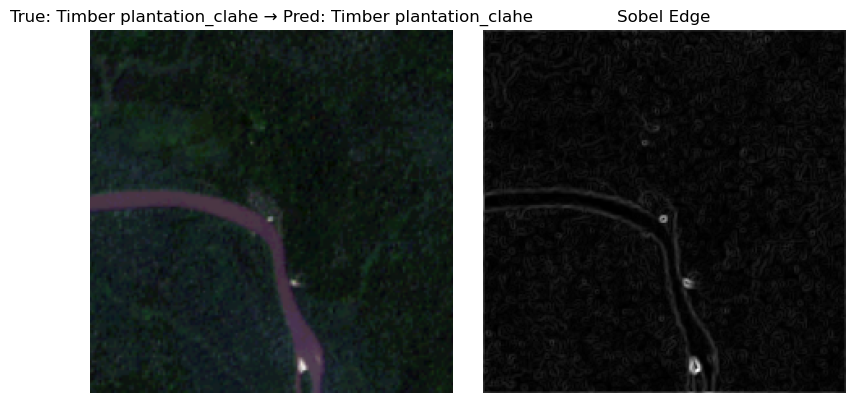

In [35]:
# 8) Visualize some predictions ------------------------------------------------------
class_names = [d.name for d in clahe_dirs]
idx = random.randint(0, len(val_ds)-1)
img_tensor, true_label = val_ds[idx]
advanced_model.eval()
with torch.no_grad():
    pred_idx = advanced_model(img_tensor.unsqueeze(0).to(device)).argmax(dim=1).item()

# prepare display
rgb = img_tensor[:3].clone()
for t, m, s in zip(rgb, imagenet_mean, imagenet_std):
    t.mul_(s).add_(m)
rgb = rgb.permute(1,2,0).cpu().numpy()
rgb_disp = np.clip(rgb * 255, 0, 255).astype(np.uint8)
edge = img_tensor[3].cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,4))
ax1.imshow(rgb_disp)
ax1.set_title(f"True: {class_names[true_label]} → Pred: {class_names[pred_idx]}")
ax1.axis("off")

ax2.imshow(edge, cmap="gray")
ax2.set_title("Sobel Edge")
ax2.axis("off")

plt.tight_layout()
plt.show()

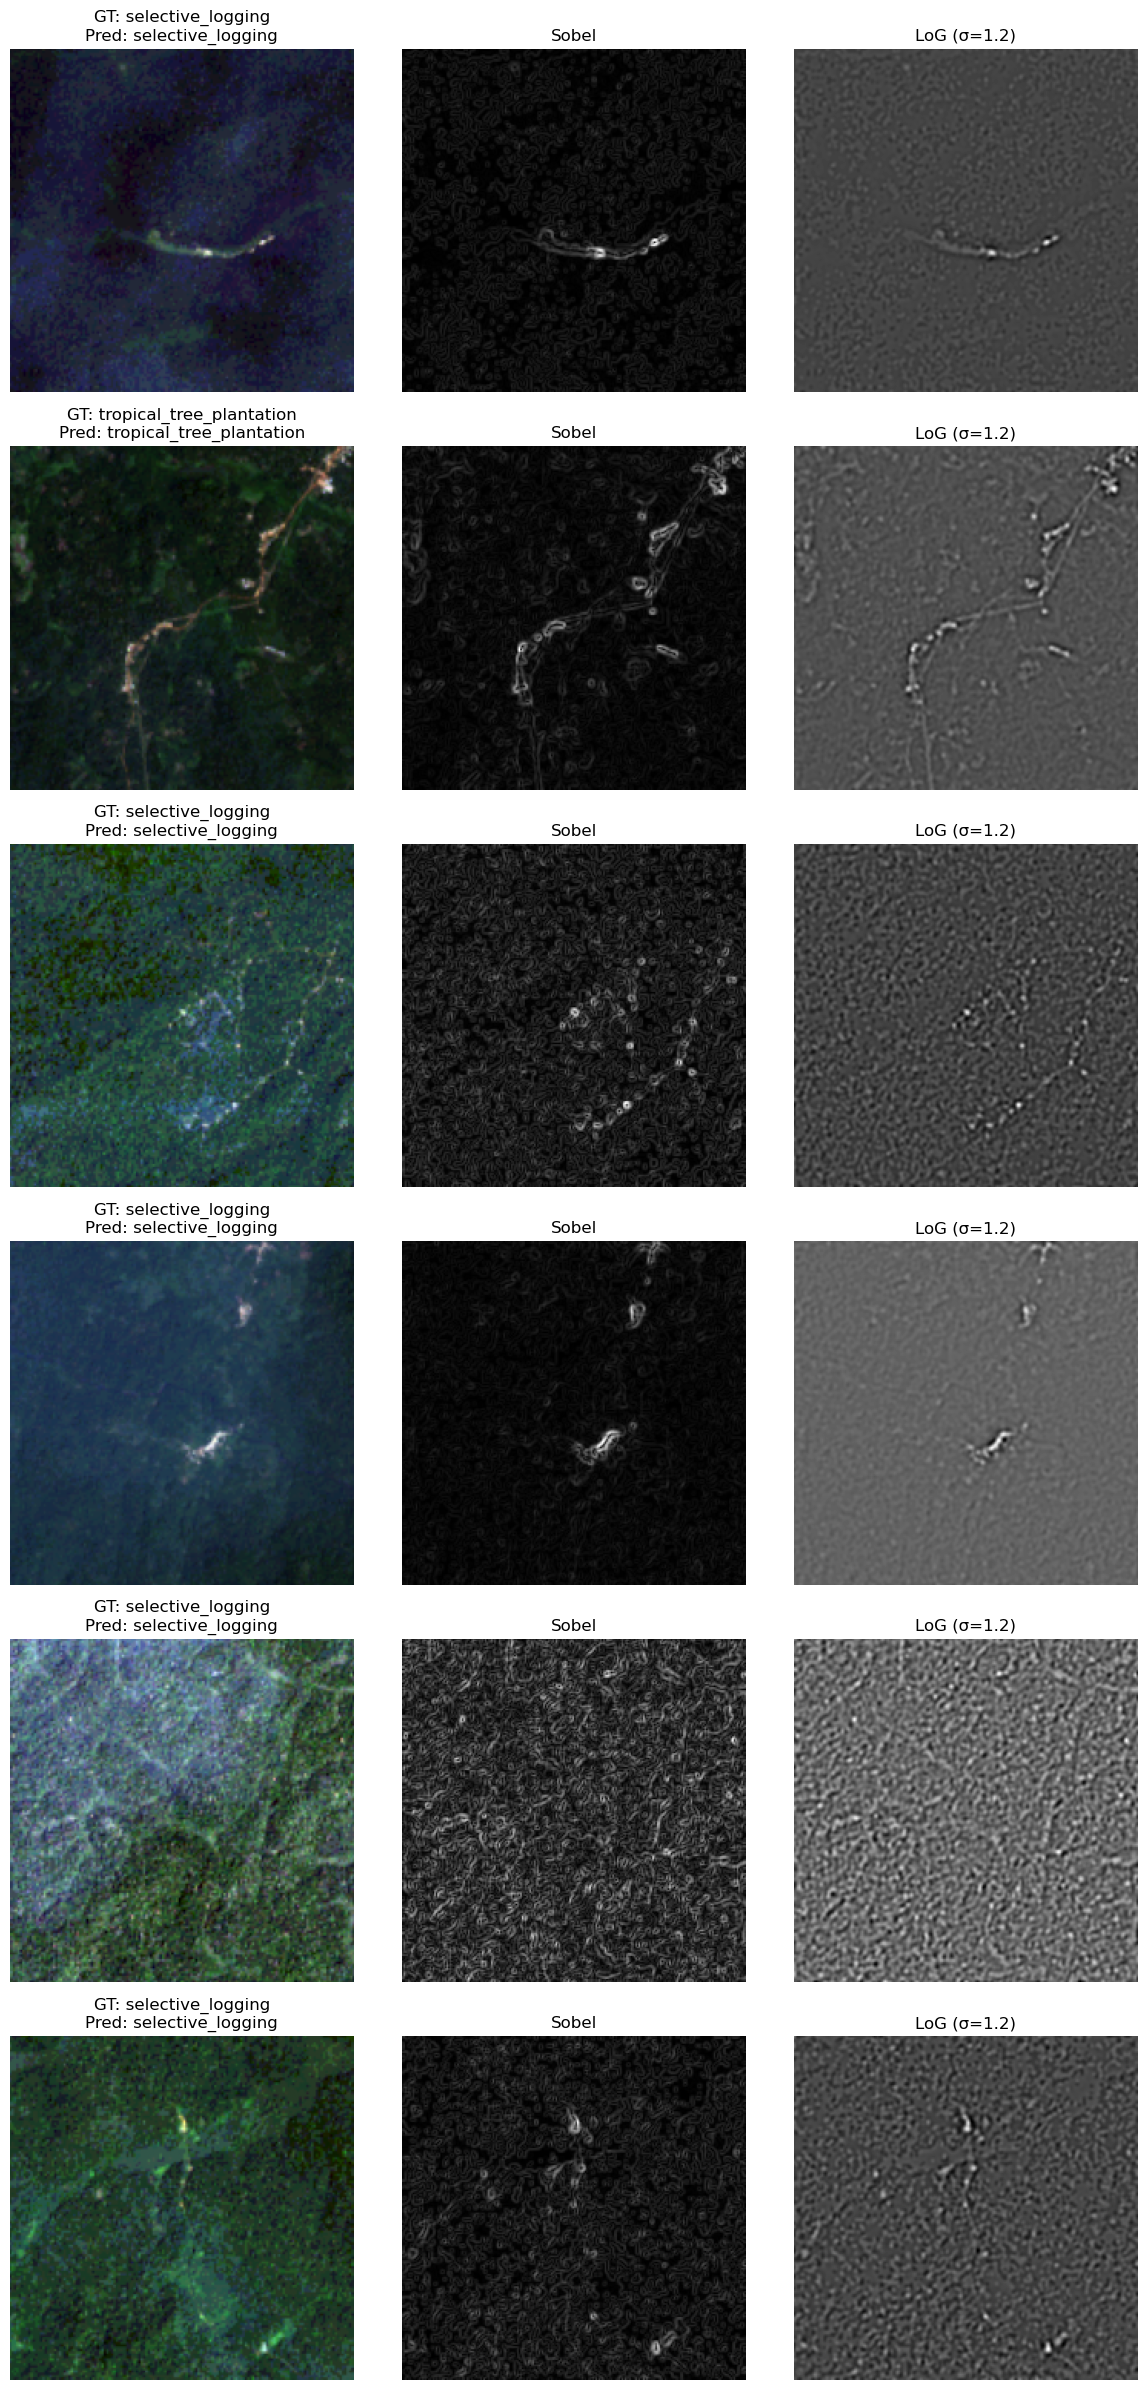

In [56]:
# ─── CONFIG ────────────────────────────────────────────────────────────────────
NUM_EXAMPLES = 6
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
inv_norm = Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std =[1/s   for s   in std]
)
LOG_SIGMA = 1.2
# ────────────────────────────────────────────────────────────────────────────────

# pull out your validation dataset
dataset   = val_loader.dataset
# get class names straight off your Dataset (works if you've set `self.classes = [...]`)
if hasattr(dataset, "classes"):
    class_names = dataset.classes
else:
    # fallback: manually list all your multiclass labels here in order
    class_names = ["maize_plantation", "selective_logging", "tropical_tree_plantation", "wildfire"]  

# sample some random indices
indices = random.sample(range(len(dataset)), min(NUM_EXAMPLES, len(dataset)))

# set up the grid: NUM_EXAMPLES rows × 3 cols
fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))

advanced_model.eval()
with torch.no_grad():
    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]       # shape [C, H, W]
        # --- RGB display (first 3 bands) ----------------------------
        rgb_disp = (
            inv_norm(img_tensor[:3])
            .permute(1, 2, 0)                         # [H, W, 3]
            .clamp(0, 1)
            .cpu()
            .numpy()
        )
        gray      = rgb2gray(rgb_disp)

        # --- Edge maps ----------------------------------------------
        sobel_map = sobel(gray)
        log_map   = laplace(gaussian(gray, sigma=LOG_SIGMA))

        # --- Model prediction ---------------------------------------
        logits   = model(img_tensor.unsqueeze(0).to(device))
        pred_idx = logits.argmax(dim=1).item()

        # --- Plot ----------------------------------------------------
        ax_rgb, ax_sobel, ax_log = axes[row]
        ax_rgb.imshow(rgb_disp)
        ax_rgb.set_title(f"GT: {class_names[true_label]}\nPred: {class_names[pred_idx]}")
        ax_rgb.axis("off")

        ax_sobel.imshow(sobel_map, cmap="gray")
        ax_sobel.set_title("Sobel")
        ax_sobel.axis("off")

        ax_log.imshow(log_map, cmap="gray")
        ax_log.set_title(f"LoG (σ={LOG_SIGMA})")
        ax_log.axis("off")

plt.tight_layout()
plt.show()

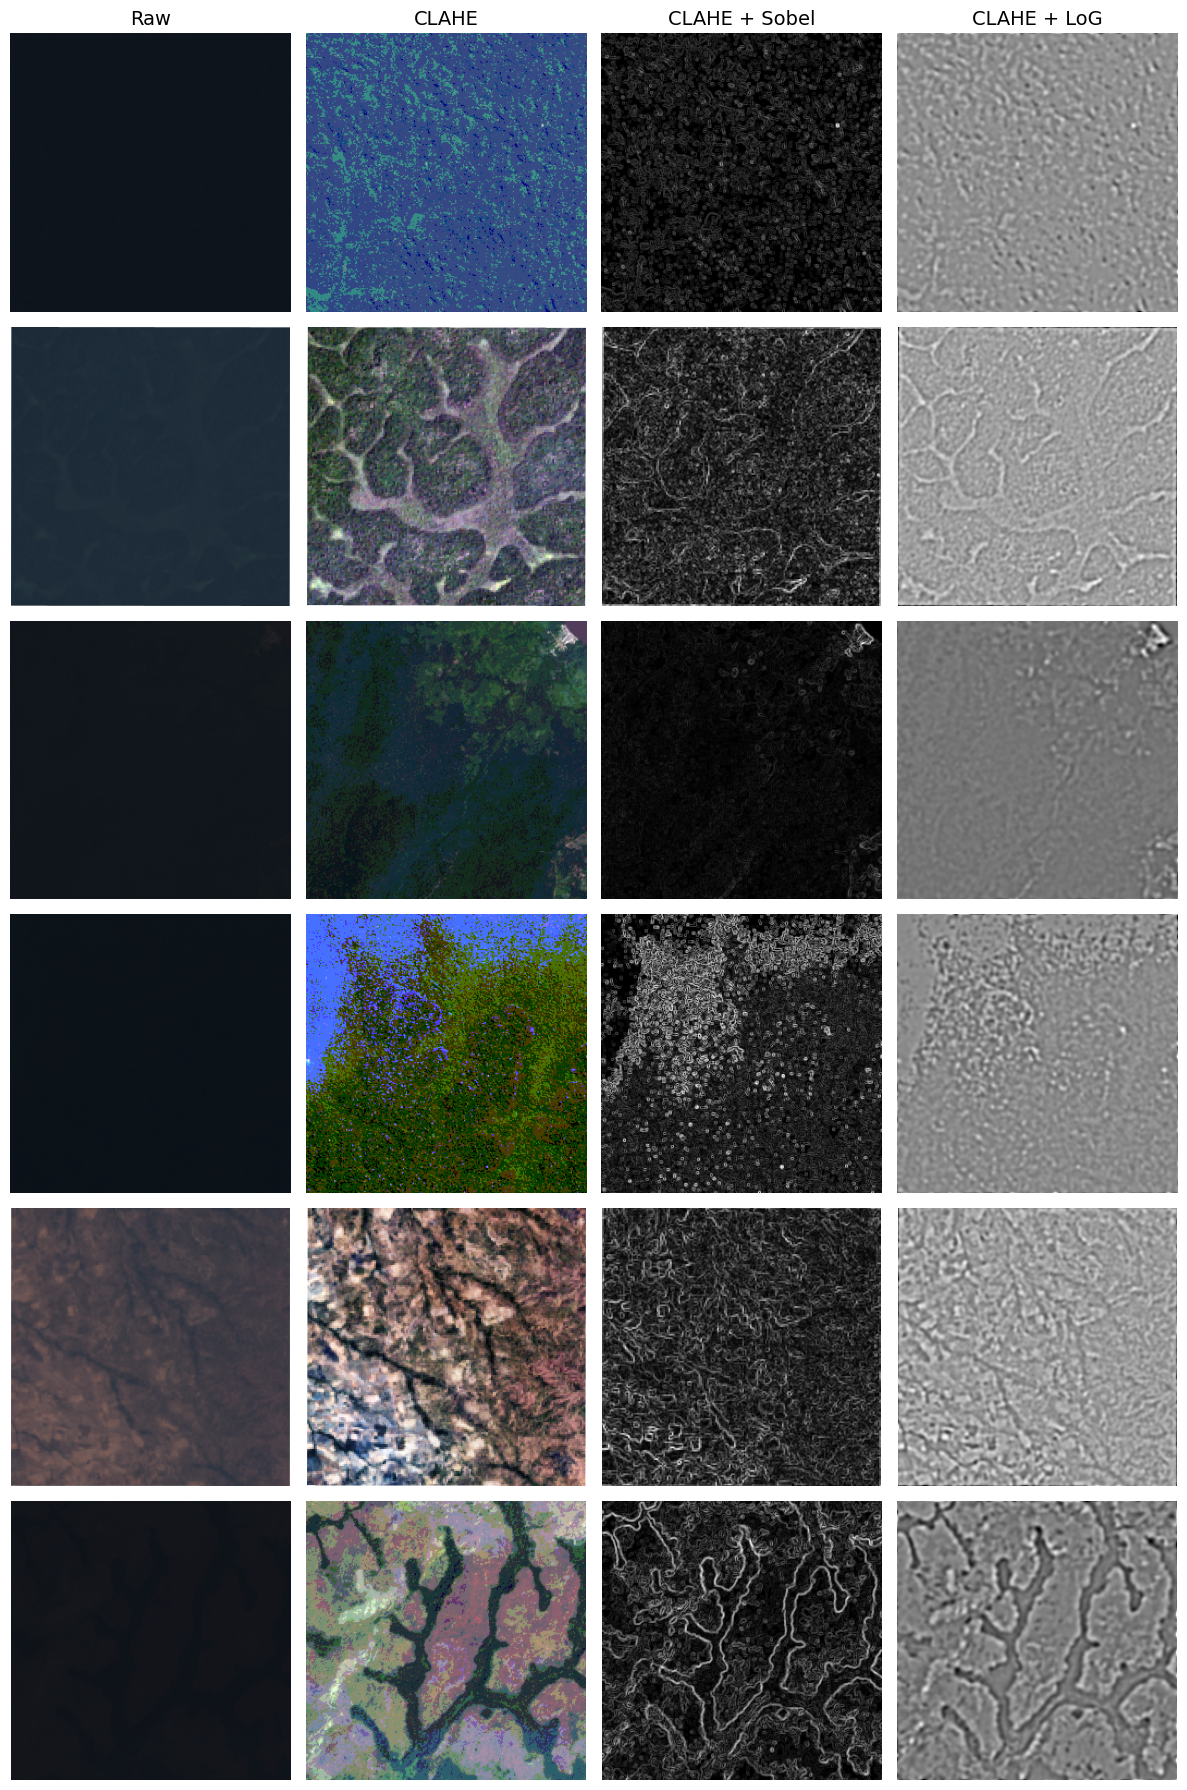

In [99]:
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, exposure
from skimage.filters import sobel, laplace, gaussian

# ─── Configuration ─────────────────────────────────────────────────────────────
BASE_DIR = Path(r"C:\Users\oliwa\Documents\capstone\images_for_modeling\combined_deforestation_drivers")

# Gather “raw” class folders (those without the “_clahe” suffix)
raw_dirs = [d for d in BASE_DIR.iterdir() if d.is_dir() and not d.name.endswith("_clahe")]

# Collect all PNG paths from those folders
raw_paths = [p for d in raw_dirs for p in d.glob("*.png")]

# Pull 6 random examples
samples = random.sample(raw_paths, 6)

# ─── Plot a 6‐row × 4‐column grid ────────────────────────────────────────────────
fig, axes = plt.subplots(6, 4, figsize=(12, 18))
col_titles = ["Raw", "CLAHE", "CLAHE + Sobel", "CLAHE + LoG"]

# Set column titles
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=14)

for row, raw_path in enumerate(samples):
    # 1) Load & normalize raw
    raw = io.imread(raw_path).astype(np.float32)
    if raw.max() > 1.0:
        raw /= 255.0

    # 2) Apply CLAHE per channel
    clahe = np.zeros_like(raw)
    for c in range(raw.shape[2]):
        clahe[..., c] = exposure.equalize_adapthist(
            raw[..., c],
            clip_limit=0.03
        )

    # 3) Convert to grayscale for edge filters
    gray = np.mean(clahe, axis=2)
    sobel_img = sobel(gray)
    log_img = laplace(gaussian(gray, sigma=2))

    # 4) Display each variant
    variants = [raw, clahe, sobel_img, log_img]
    for col, img in enumerate(variants):
        ax = axes[row, col]
        if col < 2:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap="gray")
        ax.axis("off")

plt.tight_layout()
plt.show()


In [74]:
print("class_map:", class_map)
print("  contains indices:", list(class_map.keys()))
print("logits shape:", logits.shape)
print("pred_idx:", pred_idx)

class_map: {'maize_plantation_clahe': 0, 'selective_logging_clahe': 1, 'tropical_tree_plantation_clahe': 2, 'wildfire_clahe': 3, 'undisturbed_forest_clahe': 4}
  contains indices: ['maize_plantation_clahe', 'selective_logging_clahe', 'tropical_tree_plantation_clahe', 'wildfire_clahe', 'undisturbed_forest_clahe']
logits shape: torch.Size([1, 5])
pred_idx: 4
